# Sparse Bundle Adjustment

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from time import time
from lib import misc, utils, app

plt.style.use(os.path.join('..', 'configs', 'mplstyle.yaml'))

%load_ext autoreload
%autoreload 2

ROOT_DATA_DIR = os.path.join("..", "data")

# Reconstruction Params
Define the params in the cell below. Thereafter, run all cells

In [3]:
DATA_DIR = os.path.join(ROOT_DATA_DIR, "20250806")

start_frame = 1
end_frame = 500

# DLC p_cutoff - any points with likelihood < dlc_thresh are not trusted in optimisation
dlc_thresh = 0.5 # change this only if the optimisation result is unsatisfactory

# Optimization

Initialization took 0.17 seconds

Loaded extrinsics from ../data/20250806/extrinsic_calib/3_cam_scene_sba.json

Found 6000 pairwise points between camera 0 and 1
Found 5837 pairwise points between camera 1 and 2
Found 4153 pairwise points between camera 2 and 0

bundle_adjust_points_only
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.7372e+07                                    8.29e+04    
       1             17         9.5144e+07      2.23e+06       3.19e+00       8.29e+04    
       2             18         9.4767e+07      3.78e+05       3.54e+00       8.29e+04    
       3             19         9.4384e+07      3.83e+05       8.62e-01       8.29e+04    
       4             20         9.4143e+07      2.40e+05       1.65e+00       8.29e+04    
       5             21         9.4018e+07      1.25e+05       1.51e+00       8.29e+04    
       6             22         9.4017e+07      1.15e+03       1.55e+00   

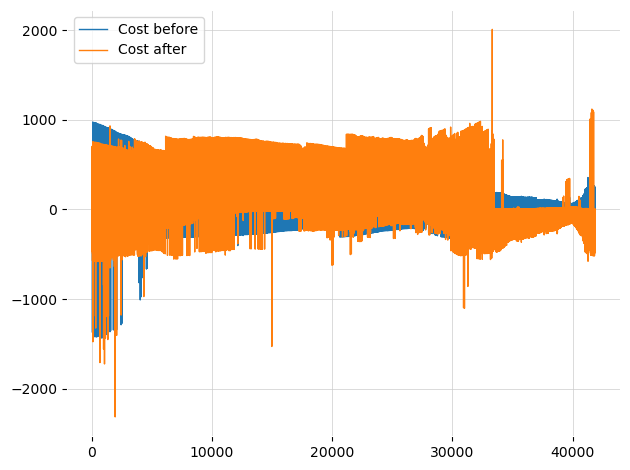

In [4]:
t0 = time()

assert os.path.exists(DATA_DIR)
OUT_DIR = os.path.join(DATA_DIR, 'sba')
DLC_DIR = os.path.join(DATA_DIR, 'dlc')
assert os.path.exists(DLC_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

app.start_logging(os.path.join(OUT_DIR, 'sba.log'))

# load video info
res, fps, tot_frames, _ = app.get_vid_info(DATA_DIR) # path to original videos
assert end_frame <= tot_frames, f'end_frame must be less than or equal to {tot_frames}'

start_frame -= 1 # 0 based indexing
# assert start_frame >= 0
N = end_frame-start_frame

*_, n_cams, scene_fpath = utils.find_scene_file(DATA_DIR, verbose=False)

dlc_points_fpaths = sorted(glob(os.path.join(DLC_DIR, '*.h5')))
assert n_cams == len(dlc_points_fpaths)
    
# Load Measurement Data (pixels, likelihood)
points_2d_df = utils.load_dlc_points_as_df(dlc_points_fpaths, verbose=False)
points_2d_df = points_2d_df[points_2d_df["frame"].between(start_frame, end_frame-1)]
points_2d_df = points_2d_df[points_2d_df['likelihood']>dlc_thresh] # ignore points with low likelihood

t1 = time()
print("Initialization took {0:.2f} seconds\n".format(t1 - t0))

points_3d_df, residuals = app.sba_points_fisheye(scene_fpath, points_2d_df)

app.stop_logging()

plt.plot(residuals['before'], label="Cost before")
plt.plot(residuals['after'], label="Cost after")
plt.legend()
fig_fpath = os.path.join(OUT_DIR, 'sba.svg')
plt.savefig(fig_fpath, transparent=True)
print(f'Saved {fig_fpath}\n')
plt.show(block=False)

# Save SBA results

In [5]:
markers = misc.get_markers()

positions = np.full((N, len(markers), 3), np.nan)
for i, marker in enumerate(markers):
    marker_pts = points_3d_df[points_3d_df["marker"]==marker][["frame", "x", "y", "z"]].values
    for frame, *pt_3d in marker_pts:
        positions[int(frame)-start_frame, i] = pt_3d

app.save_sba(positions, OUT_DIR, scene_fpath, start_frame, dlc_thresh)

Saved ../data/20250806/sba/sba.pickle
Saved ../data/20250806/sba/sba.mat
Saved ../data/20250806/sba/cam*_sba.h5
Saved ../data/20250806/sba/cam*_sba.csv

Saving labeled videos...
Loading cam1 and data.Loading cam2 and data.Loading cam3 and data.



Duration of video: 49.58 s, recorded with 29.97 fps!
Total frames: 1486 with frame dimensions: 2688 x 1512
Generating frames and creating video...


  0%|          | 0/1486 [00:00<?, ?it/s]


Duration of video: 49.58 s, recorded with 29.97 fps!

Duration of video: 49.58 s, recorded with 29.97 fps!Total frames: 1486 with frame dimensions: 2688 x 1512

Total frames: 1486 with frame dimensions: 2688 x 1512Generating frames and creating video...

Generating frames and creating video...


100%|██████████| 1486/1486 [01:20<00:00, 18.39it/s]


Done!



# Plot the cheetah!

In [6]:
data_fpath = os.path.join(OUT_DIR, 'sba.pickle')
app.plot_cheetah_reconstruction(data_fpath, reprojections=False, centered=True, dark_mode=True)

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


Loaded extrinsics from ../data/20250806/extrinsic_calib/3_cam_scene_sba.json

